In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [2]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
data_location="../../../data/cifar-10-batches-py/"

In [4]:
# 1. Load a specific data batch (update the path if necessary)
batch_file = data_location+'data_batch_1' 
batch = unpickle(batch_file)

# 2. Extract data and labels
# CIFAR keys are returned as bytes, so we use b'data' and b'labels'
raw_images = batch[b'data']
labels = batch[b'labels']

# 3. Reshape the flat 3072 array to a 32x32x3 image structure
# The layout is (channels, rows, columns), so we transpose it to (rows, columns, channels)
images = raw_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# 4. (Optional) Load the metadata to get actual text names for the labels
meta_file = data_location+'batches.meta'
meta = unpickle(meta_file)
label_names = [name.decode('utf-8') for name in meta[b'label_names']]


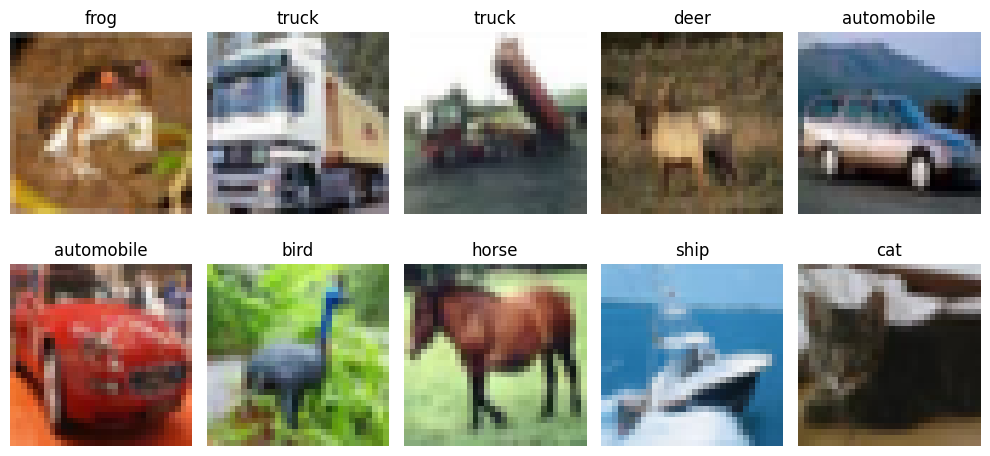

In [5]:
# 5. Plot a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i])
    axes[i].set_title(label_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Initialize lists to store data from each batch
all_images = []
all_labels = []

# Loop through all 5 batches
for i in range(1, 6):
    batch_file = data_location + f'data_batch_{i}'
    batch = unpickle(batch_file)
    
    # Extract raw data and labels
    raw_images = batch[b'data']
    labels = batch[b'labels']
    
    # Reshape and transpose individual batch images right away
    images = raw_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    # Append to our lists
    all_images.append(images)
    all_labels.extend(labels)  # use extend since b'labels' is a list

# Combine all batches into huge multidimensional numpy arrays
X = np.concatenate(all_images, axis=0)
y = np.array(all_labels)

print("Huge image array shape:", X.shape)
print("Huge labels array shape:", y.shape)

Huge image array shape: (50000, 32, 32, 3)
Huge labels array shape: (50000,)


In [8]:
# 1. Load the test batch file specifically
test_file = data_location+'test_batch' 
test_batch = unpickle(test_file)

# 2. Extract the test images and test labels
raw_test_images = test_batch[b'data']
test_labels = test_batch[b'labels']

# 3. Reshape and transpose just like before
test_images = raw_test_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Quick check to confirm the shape
print("Test images shape:", test_images.shape)  # Should output: (10000, 32, 32, 3)
print("Number of test labels:", len(test_labels))  # Should output: 10000

Test images shape: (10000, 32, 32, 3)
Number of test labels: 10000


In [9]:
Xtr_rows = X.reshape(X.shape[0], 32 * 32 * 3) # Xtr_rows becomes 50000 x 3072
Xte_rows = test_images.reshape(test_images.shape[0], 32 * 32 * 3) # Xte_rows becomes 10000 x 3072

In [10]:
import torch

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

X_train = torch.as_tensor(
    Xtr_rows,
    dtype=torch.float32,
    device=device
)

# Scale pixel values from 0–255 to 0–1
X_train = X_train / 255.0

# Optional but often helpful: center values around zero
X_train = (X_train - 0.5) / 0.5

# Class labels must be integers such as 0, 1, ..., 9
y_train = torch.as_tensor(
    y,
    dtype=torch.long,
    device=device
).reshape(-1)

number_of_features = X_train.shape[1]
number_of_classes = 10

W = torch.zeros(
    number_of_features,
    number_of_classes,
    device=device,
    requires_grad=True
)

b = torch.zeros(
    number_of_classes,
    device=device,
    requires_grad=True
)

optimizer = torch.optim.Adam(
    [W, b],
    lr=1e-3
)

loss_function = torch.nn.CrossEntropyLoss()

epochs = 100

for epoch in range(epochs):
    optimizer.zero_grad()

    # Shape: [50000, 10]
    logits = X_train @ W + b

    loss = loss_function(logits, y_train)

    if not torch.isfinite(loss):
        print(f"Invalid loss at epoch {epoch}")
        break

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        with torch.no_grad():
            predicted_classes = logits.argmax(dim=1)
            accuracy = (
                predicted_classes == y_train
            ).float().mean()

        print(
            f"Epoch {epoch:4d} "
            f"Loss = {loss.item():.6f} "
            f"Accuracy = {accuracy.item():.4f}"
        )

print("W shape:", W.shape)
print("b shape:", b.shape)

Epoch    0 Loss = 2.302585 Accuracy = 0.1000
Epoch   10 Loss = 1.850593 Accuracy = 0.3655
Epoch   20 Loss = 1.796673 Accuracy = 0.3941
Epoch   30 Loss = 1.754741 Accuracy = 0.4061
Epoch   40 Loss = 1.733755 Accuracy = 0.4152
Epoch   50 Loss = 1.717302 Accuracy = 0.4223
Epoch   60 Loss = 1.705486 Accuracy = 0.4260
Epoch   70 Loss = 1.695805 Accuracy = 0.4299
Epoch   80 Loss = 1.687717 Accuracy = 0.4327
Epoch   90 Loss = 1.680724 Accuracy = 0.4363
W shape: torch.Size([3072, 10])
b shape: torch.Size([10])


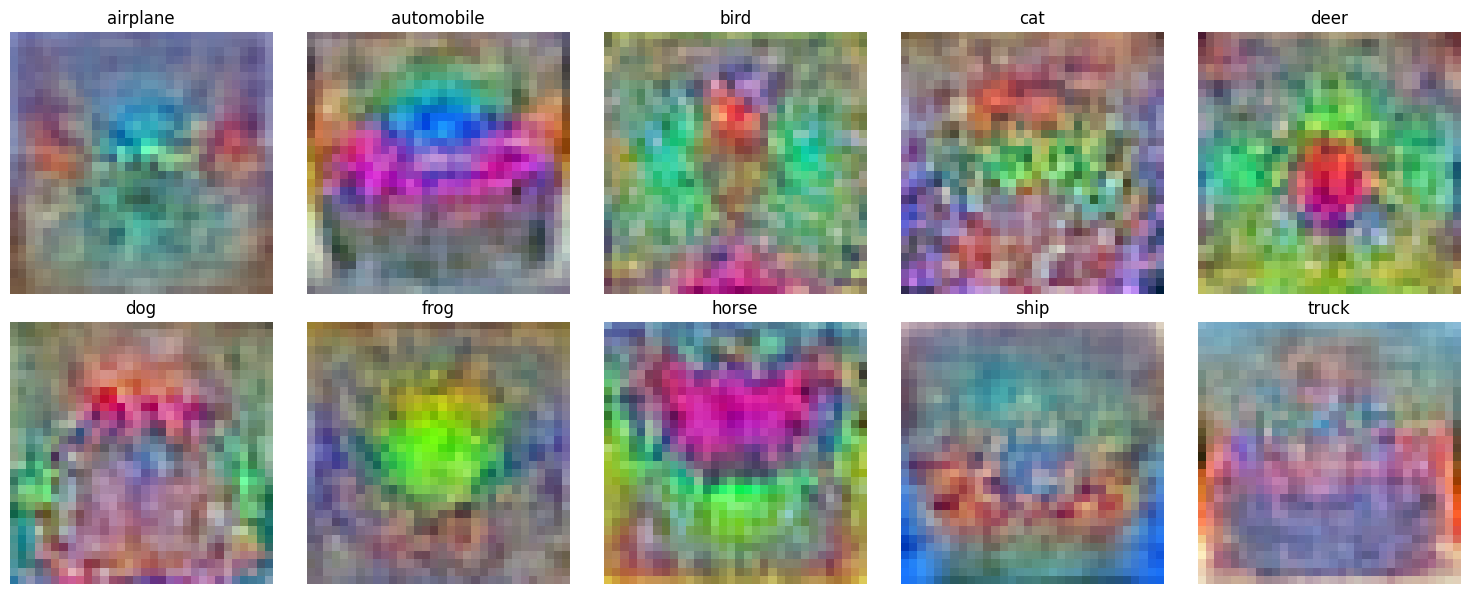

In [11]:
# Move weights from MPS/GPU to CPU and convert to NumPy

weights = W.detach().cpu().numpy()

class_names = [

    "airplane",

    "automobile",

    "bird",

    "cat",

    "deer",

    "dog",

    "frog",

    "horse",

    "ship",

    "truck"

]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for class_index, ax in enumerate(axes.flat):

    # One column contains the 3072 weights for one class

    class_weights = weights[:, class_index]

    # Use this if your flattened images originally had shape (32, 32, 3)

    weight_image = class_weights.reshape(32, 32, 3)

    # Scale weights into the visible 0–1 range

    minimum = weight_image.min()

    maximum = weight_image.max()

    normalized_image = (

        (weight_image - minimum) /

        (maximum - minimum + 1e-8)

    )

    ax.imshow(normalized_image)

    ax.set_title(class_names[class_index])

    ax.axis("off")

plt.tight_layout()

plt.show()